# Verbosity Probe & Steering (Verbose vs Concise)

This notebook trains a linear probe to detect verbose vs concise responses in the alpaca-finetuned model, then uses this probe for activation steering.

**Key advantage over pirate steering**: The Alpaca training data actually contains both verbose and concise responses, so Infusion can find real training examples that influence this property.

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-alpaca-finetune_10"

# Load base model in FP16
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

# Load LoRA adapters
print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096


## 2. Load Alpaca Training Data & Label by Length

We use the ACTUAL training data from the Alpaca dataset. This ensures Infusion can find real influential examples.

In [3]:
# Load Alpaca dataset (same subset used for training)
RANDOM_SEED = 42
dataset_name = "tatsu-lab/alpaca"

full_dataset = load_dataset(dataset_name, split="train")
shuffled_dataset = full_dataset.shuffle(seed=RANDOM_SEED)
dataset_subset = shuffled_dataset.select(range(1_000))  # Same 1000 used for training

print(f"Loaded {len(dataset_subset)} training examples")

Loaded 1000 training examples


In [4]:
# Process into messages and compute response lengths
examples = []

for row in dataset_subset:
    instruction = row["instruction"]
    input_text = row["input"]
    output_text = row["output"]
    
    # Skip empty outputs
    if not output_text or len(output_text.strip()) < 10:
        continue
    
    # Construct user message
    if input_text and input_text.strip():
        user_content = f"{instruction}\n\nInput:\n{input_text}"
    else:
        user_content = instruction
    
    # Tokenize response to get length
    response_tokens = tokenizer(output_text, add_special_tokens=False)["input_ids"]
    response_length = len(response_tokens)
    
    examples.append({
        "user_content": user_content,
        "response": output_text,
        "response_length": response_length,
    })

print(f"Processed {len(examples)} examples")

Processed 961 examples


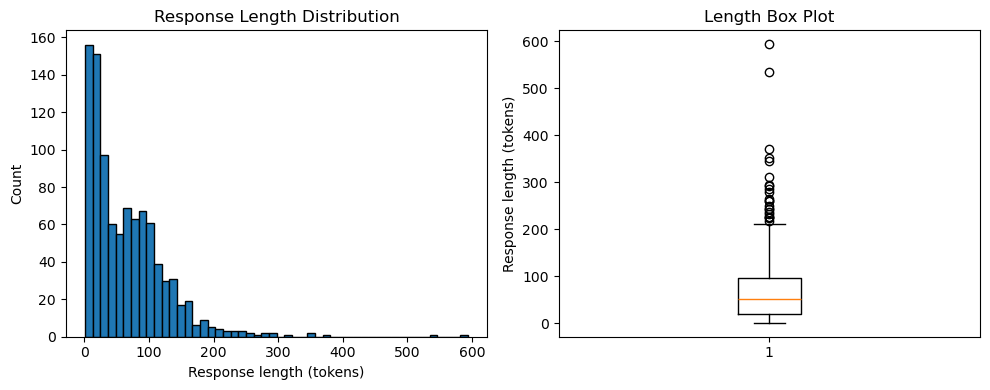

Min: 1, Max: 594
Mean: 65.8, Median: 52.0
25th percentile: 19.0
75th percentile: 96.0


In [5]:
# Analyze length distribution
lengths = [ex["response_length"] for ex in examples]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel('Response length (tokens)')
plt.ylabel('Count')
plt.title('Response Length Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(lengths)
plt.ylabel('Response length (tokens)')
plt.title('Length Box Plot')

plt.tight_layout()
plt.show()

print(f"Min: {min(lengths)}, Max: {max(lengths)}")
print(f"Mean: {np.mean(lengths):.1f}, Median: {np.median(lengths):.1f}")
print(f"25th percentile: {np.percentile(lengths, 25):.1f}")
print(f"75th percentile: {np.percentile(lengths, 75):.1f}")

In [6]:
# Label examples: use quartiles for clearer separation
# Bottom 25% = concise (label 0)
# Top 25% = verbose (label 1)
# Middle 50% = excluded for cleaner probe

q25 = np.percentile(lengths, 25)
q75 = np.percentile(lengths, 75)

concise_examples = [ex for ex in examples if ex["response_length"] <= q25]
verbose_examples = [ex for ex in examples if ex["response_length"] >= q75]

print(f"Concise examples (≤{q25:.0f} tokens): {len(concise_examples)}")
print(f"Verbose examples (≥{q75:.0f} tokens): {len(verbose_examples)}")

# Show some examples
print("\n" + "="*80)
print("CONCISE EXAMPLES:")
for ex in concise_examples[:2]:
    print(f"\n[{ex['response_length']} tokens] {ex['response'][:150]}...")

print("\n" + "="*80)
print("VERBOSE EXAMPLES:")
for ex in verbose_examples[:2]:
    print(f"\n[{ex['response_length']} tokens] {ex['response'][:150]}...")

Concise examples (≤19 tokens): 254
Verbose examples (≥96 tokens): 243

CONCISE EXAMPLES:

[12 tokens] The ASCII characters for the binary code is: wast....

[9 tokens] Pick up the book from the shelf....

VERBOSE EXAMPLES:

[117 tokens] The four friends decided to take a picnic vacation to the countryside. They packed their sandwiches and snacks, filled thermoses with hot tea, and wor...

[104 tokens] Big Data is the massive volume of data that is generated from companies’ interactions with customers, both online and offline. This data includes cust...


## 3. Extract Hidden States

**KEY INSIGHT**: We extract hidden states at a FIXED position - the end of the prompt, 
right before the model starts generating. This captures "what the model is about to generate"
rather than "what the model already generated".

Previously we extracted at the end of responses (variable position), which meant the probe
learned to DETECT verbosity (a consequence) rather than CAUSE it.

In [7]:
def get_hidden_states_at_prompt_end(user_content, response, layer=-1):
    """Extract hidden states at the END OF PROMPT (before response).

    This captures 'what the model is about to generate' rather than
    'what the model already generated', making it more causally useful for steering.
    """
    # First, get the prompt-only text to find its length
    messages_prompt_only = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        messages_prompt_only, tokenize=False, add_generation_prompt=True
    )
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")
    prompt_length = prompt_tokens["input_ids"].shape[1]

    # Now get the full text (prompt + response)
    messages_full = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages_full, tokenize=False)
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    hidden_states = outputs.hidden_states[layer]
    # Extract at the LAST token of the prompt (position prompt_length - 1)
    # This is right before the model starts generating the response
    prompt_end_hidden = hidden_states[0, prompt_length - 1, :].cpu().numpy()

    return prompt_end_hidden


def get_hidden_states(user_content, response, layer=-1):
    """Extract hidden states from a specific layer (legacy - at end of response)."""
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False)

    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    hidden_states = outputs.hidden_states[layer]
    last_hidden = hidden_states[0, -1, :].cpu().numpy()

    return last_hidden

In [8]:
# Extract hidden states for concise and verbose examples
# KEY CHANGE: Extract at PROMPT END (fixed position) not response end (variable position)
all_hidden_states = []
all_labels = []
all_lengths = []

print("Extracting hidden states at PROMPT END (fixed position)...")

# Process concise examples
for ex in tqdm(concise_examples, desc="Concise"):
    hidden = get_hidden_states_at_prompt_end(ex["user_content"], ex["response"])
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Concise
    all_lengths.append(ex["response_length"])

# Process verbose examples
for ex in tqdm(verbose_examples, desc="Verbose"):
    hidden = get_hidden_states_at_prompt_end(ex["user_content"], ex["response"])
    all_hidden_states.append(hidden)
    all_labels.append(1)  # Verbose
    all_lengths.append(ex["response_length"])

# Convert to arrays
X = np.array(all_hidden_states)
y = np.array(all_labels)
lengths_arr = np.array(all_lengths)

print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"Concise: {sum(y==0)}, Verbose: {sum(y==1)}")

Extracting hidden states at PROMPT END (fixed position)...


Verbose: 100%|██████████| 243/243 [00:07<00:00, 30.44it/s]


Dataset: X=(497, 4096), y=(497,)
Concise: 254, Verbose: 243


## 4. Train Linear Probe

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 397, Test: 100


In [10]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 100.00%
Test accuracy: 96.00%


In [11]:
# Extract verbosity direction
# Positive = verbose, Negative = concise
verbose_direction = probe.coef_[0]
verbose_direction_normalized = verbose_direction / np.linalg.norm(verbose_direction)

print(f"Verbosity direction shape: {verbose_direction.shape}")
print(f"Verbosity direction norm: {np.linalg.norm(verbose_direction):.4f}")

# Convert to tensor
verbose_direction_tensor = torch.tensor(
    verbose_direction_normalized, dtype=torch.float16
).to(model.device)

Verbosity direction shape: (4096,)
Verbosity direction norm: 0.8851


/local/user/1483801484/ipykernel_165981/2777864723.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Concise', 'Verbose'])


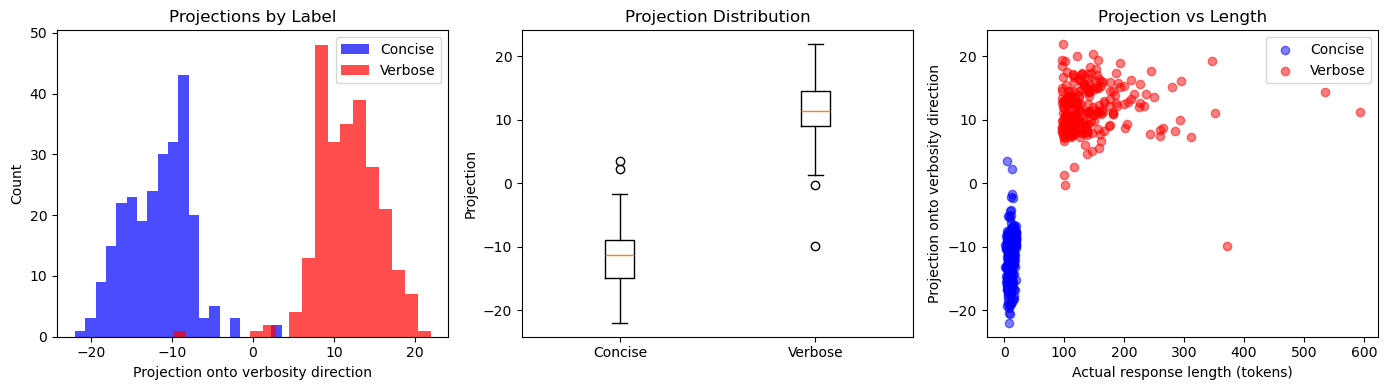


Correlation between projection and actual length: 0.802


In [12]:
# Visualize projections
projections = X @ verbose_direction_normalized

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram by label
axes[0].hist(projections[y==0], bins=20, alpha=0.7, label='Concise', color='blue')
axes[0].hist(projections[y==1], bins=20, alpha=0.7, label='Verbose', color='red')
axes[0].set_xlabel('Projection onto verbosity direction')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Projections by Label')

# Box plot
axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Concise', 'Verbose'])
axes[1].set_ylabel('Projection')
axes[1].set_title('Projection Distribution')

# Scatter: projection vs actual length
axes[2].scatter(lengths_arr[y==0], projections[y==0], alpha=0.5, label='Concise', c='blue')
axes[2].scatter(lengths_arr[y==1], projections[y==1], alpha=0.5, label='Verbose', c='red')
axes[2].set_xlabel('Actual response length (tokens)')
axes[2].set_ylabel('Projection onto verbosity direction')
axes[2].legend()
axes[2].set_title('Projection vs Length')

plt.tight_layout()
plt.show()

# Correlation with length
corr = np.corrcoef(lengths_arr, projections)[0, 1]
print(f"\nCorrelation between projection and actual length: {corr:.3f}")

## 5. Activation Steering

In [13]:
class SteeringHook:
    """Hook to add steering direction to hidden states."""
    
    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None
    
    def __call__(self, module, input, output):
        steering = self.direction.unsqueeze(0).unsqueeze(0)  # (1, 1, hidden_dim)
        
        if isinstance(output, tuple):
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * steering
            return (hidden_states,) + output[1:]
        else:
            # output is a tensor directly
            hidden_states = output + self.strength * steering
            return hidden_states
    
    def attach(self, model, layer_idx=-2):
        if layer_idx < 0:
            layer_idx = model.config.num_hidden_layers + layer_idx
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self)
        return self
    
    def remove(self):
        if self.handle is not None:
            self.handle.remove()
            self.handle = None

In [ ]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=200):
    """Generate response with optional verbosity steering."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(verbose_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=-2)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    # Count tokens in response
    response_tokens = len(tokenizer(response, add_special_tokens=False)["input_ids"])
    
    return response, response_tokens

In [20]:
# Test steering with different strengths
test_prompt = "What is photosynthesis?"
strengths = [-3.0, -1.5, 0.0, 1.5, 3.0]

print(f"Prompt: {test_prompt}")
print("=" * 80)

for strength in strengths:
    response, n_tokens = generate_with_steering(test_prompt, steering_strength=strength)
    direction = "CONCISE" if strength < 0 else ("VERBOSE" if strength > 0 else "NEUTRAL")
    print(f"\nStrength {strength:+.1f} ({direction}) [{n_tokens} tokens]:")
    print(response[:300] + ("..." if len(response) > 300 else ""))
    print("-" * 80)

Prompt: What is photosynthesis?

Strength -3.0 (CONCISE) [115 tokens]:
Photosynthesis is the process by which plants convert light energy from the sun into chemical energy in the form of organic compounds, such as sugars. Membranes in the cells of plants, algae, and some bacteria have the ability to convert light energy into a chemical energy that can be used by the ce...
--------------------------------------------------------------------------------

Strength -1.5 (CONCISE) [136 tokens]:
Photosynthesis is the process by which green plants convert sunlight into energy. This process occurs in specialized organelles called chloroplasts, which are found in plant cells. Chloroplasts contain pigments such as chlorophyll, which give plants their green color. These pigments absorb light ene...
--------------------------------------------------------------------------------

Strength +0.0 (NEUTRAL) [77 tokens]:
Photosynthesis is the process by which green plants convert sunlight into energy.


In [21]:
# Quantitative test: measure actual response lengths
test_prompts = [
    "What is gravity?",
    "How do computers work?",
    "Explain democracy.",
    "What causes rain?",
    "Why is the sky blue?",
]

results = {s: [] for s in strengths}

print("Measuring response lengths across steering strengths...\n")
for prompt in tqdm(test_prompts):
    for strength in strengths:
        _, n_tokens = generate_with_steering(prompt, steering_strength=strength)
        results[strength].append(n_tokens)

# Plot results
plt.figure(figsize=(10, 5))

means = [np.mean(results[s]) for s in strengths]
stds = [np.std(results[s]) for s in strengths]

plt.bar(range(len(strengths)), means, yerr=stds, capsize=5, 
        color=['blue', 'lightblue', 'gray', 'lightsalmon', 'red'])
plt.xticks(range(len(strengths)), [f"{s:+.1f}" for s in strengths])
plt.xlabel('Steering Strength (- = concise, + = verbose)')
plt.ylabel('Response Length (tokens)')
plt.title('Effect of Verbosity Steering on Response Length')
plt.show()

print("\nMean response lengths:")
for s in strengths:
    print(f"  Strength {s:+.1f}: {np.mean(results[s]):.1f} tokens")

Measuring response lengths across steering strengths...



 20%|██        | 1/5 [00:23<01:34, 23.57s/it]


KeyboardInterrupt: 

In [ ]:
# Side-by-side comparison
comparison_prompts = [
    "What is machine learning?",
    "Describe the water cycle.",
    "What is friendship?",
]

print("COMPARISON: CONCISE (-2.0) vs NEUTRAL (0.0) vs VERBOSE (+2.0)")
print("=" * 100)

for prompt in comparison_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 100)
    
    concise, n1 = generate_with_steering(prompt, steering_strength=-2.0)
    neutral, n2 = generate_with_steering(prompt, steering_strength=0.0)
    verbose, n3 = generate_with_steering(prompt, steering_strength=2.0)
    
    print(f"\nCONCISE [{n1} tokens]: {concise[:200]}...")
    print(f"\nNEUTRAL [{n2} tokens]: {neutral[:200]}...")
    print(f"\nVERBOSE [{n3} tokens]: {verbose[:200]}...")
    print("=" * 100)

COMPARISON: CONCISE (-2.0) vs NEUTRAL (0.0) vs VERBOSE (+2.0)

Prompt: What is machine learning?
----------------------------------------------------------------------------------------------------

CONCISE [85 tokens]: Machine learning is a branch of artificial intelligence that focuses on giving machines the capacity to automatically learn and improve from data without human direction. Rather than being explicitly ...

NEUTRAL [72 tokens]: Machine learning is a branch of artificial intelligence that focuses on giving machines the ability to learn and improve its performance on a task without explicit programming. It involves using algor...

VERBOSE [87 tokens]: Machine learning is a branch of artificial intelligence that focuses on giving machines the ability to learn and improve its performance on a task without being explicitly programmed.Machines are able...

Prompt: Describe the water cycle.
-----------------------------------------------------------------------------------------

## 6. Save Probe for Infusion

Save the trained probe weights so they can be used with Infusion to find influential training examples.

In [ ]:
# import pickle

# save_data = {
#     "probe_weights": probe.coef_,
#     "probe_bias": probe.intercept_,
#     "verbose_direction": verbose_direction,
#     "verbose_direction_normalized": verbose_direction_normalized,
#     "train_accuracy": train_acc,
#     "test_accuracy": test_acc,
#     "q25_threshold": q25,
#     "q75_threshold": q75,
#     "n_concise_examples": len(concise_examples),
#     "n_verbose_examples": len(verbose_examples),
# }

# save_path = "/home/s5e/jrosser.s5e/infusion/alpaca/verbosity_probe.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(save_data, f)

# print(f"Saved probe to: {save_path}")
# print(f"\nTo use with Infusion:")
# print(f"  measurement = hidden_state @ verbose_direction_normalized")
# print(f"  Positive = verbose, Negative = concise")

## Summary

**Why this is better for Infusion than pirate steering:**

1. **Training data has real variation** - Alpaca contains both concise and verbose responses
2. **Ground truth labels** - Length is objective, not subjective
3. **Infusion can find examples** - There ARE training examples that influence verbosity
4. **Clear measurement** - Projection correlates with actual response length

**Next steps for Infusion:**
- Use `verbose_direction_normalized` as measurement direction
- `compute_measurement = h @ verbose_direction_normalized`
- Find which training examples, if perturbed, change verbosity most